In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

In [ ]:
plt.style.use('ggplot')
sns.set_palette("Set2")
%matplotlib inline

In [ ]:
print("Libraries imported successfully!")
print(f"Pandas version: {pd.__version__}")
print(f"NumPy version: {np.__version__}")
print(f"Seaborn version: {sns.__version__}")

Libraries imported successfully!
Pandas version: 2.2.2
NumPy version: 2.0.2
Seaborn version: 0.13.2


In [ ]:
from google.colab import files

print("Please upload your Online Retail dataset file")
print("Accepted formats: .xlsx or .csv")
print("="*50)

uploaded = files.upload()

for filename in uploaded.keys():
    print(f"File successfully uploaded: {filename}")

Please upload your Online Retail dataset file
Accepted formats: .xlsx or .csv


Saving Online Retail.xlsx to Online Retail.xlsx
File successfully uploaded: Online Retail.xlsx


In [ ]:
import os

file_name = None
for f in os.listdir():
    if 'Online' in f or 'retail' in f.lower():
        file_name = f
        break

if file_name:
    if file_name.endswith('.xlsx'):
        df = pd.read_excel(file_name)
    else:
        df = pd.read_csv(file_name, encoding='latin1')

    print(f"Dataset loaded successfully: {file_name}")
    print(f"Total rows: {len(df):,}")
    print(f"Total columns: {len(df.columns)}")
else:
    print("File not found. Please make sure you uploaded the file.")

Dataset loaded successfully: Online Retail.xlsx
Total rows: 541,909
Total columns: 8


In [ ]:
print("="*50)
print("FIRST 5 ROWS OF DATASET")
print("="*50)
df.head()

FIRST 5 ROWS OF DATASET


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


In [ ]:
print("="*50)
print("DATASET INFORMATION")
print("="*50)
df.info()

DATASET INFORMATION
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    541909 non-null  object        
 1   StockCode    541909 non-null  object        
 2   Description  540455 non-null  object        
 3   Quantity     541909 non-null  int64         
 4   InvoiceDate  541909 non-null  datetime64[ns]
 5   UnitPrice    541909 non-null  float64       
 6   CustomerID   406829 non-null  float64       
 7   Country      541909 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 33.1+ MB


In [ ]:
print("="*50)
print("DATA CLEANING PROCESS")
print("="*50)


DATA CLEANING PROCESS


In [ ]:
original_rows = len(df)
print(f"Original rows: {original_rows:,}")

Original rows: 541,909


In [ ]:
df = df.dropna(subset=['CustomerID'])
print(f"After removing missing CustomerID: {len(df):,} rows")

After removing missing CustomerID: 406,829 rows


In [ ]:
df = df[df['Quantity'] > 0]
print(f"After removing negative/zero Quantity: {len(df):,} rows")

After removing negative/zero Quantity: 397,924 rows


In [ ]:
df = df[df['UnitPrice'] > 0]
print(f"After removing invalid UnitPrice: {len(df):,} rows")

After removing invalid UnitPrice: 397,884 rows


In [ ]:
df = df[~df['InvoiceNo'].astype(str).str.contains('C', na=False)]
print(f"After removing cancellation invoices: {len(df):,} rows")

After removing cancellation invoices: 397,884 rows


In [ ]:
print("="*50)
print(f"FINAL CLEANED DATASET: {len(df):,} rows")
print(f"Rows removed: {original_rows - len(df):,} ({((original_rows - len(df))/original_rows*100):.1f}%)")

FINAL CLEANED DATASET: 397,884 rows
Rows removed: 144,025 (26.6%)


In [ ]:
print("="*50)
print("DESCRIPTIVE STATISTICS (AFTER CLEANING)")
print("="*50)
df[['Quantity', 'UnitPrice']].describe()

DESCRIPTIVE STATISTICS (AFTER CLEANING)


,Quantity,UnitPrice
count,397884.000000,397884.000000
mean,12.988238,3.116488
std,179.331775,22.097877
min,1.000000,0.001000
25%,2.000000,1.250000
50%,6.000000,1.950000
75%,12.000000,3.750000
max,80995.000000,8142.750000


In [ ]:
print("="*50)
print("DATASET INFO (AFTER CLEANING)")
print("="*50)
df.info()

DATASET INFO (AFTER CLEANING)
<class 'pandas.core.frame.DataFrame'>
Index: 397884 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    397884 non-null  object        
 1   StockCode    397884 non-null  object        
 2   Description  397884 non-null  object        
 3   Quantity     397884 non-null  int64         
 4   InvoiceDate  397884 non-null  datetime64[ns]
 5   UnitPrice    397884 non-null  float64       
 6   CustomerID   397884 non-null  float64       
 7   Country      397884 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 27.3+ MB


In [ ]:
print("UNIQUE STOCKCODE VALUES (first 20):")
print(df['StockCode'].unique()[:20])

print("\nUNUSUAL STOCKCODE PATTERNS:")
unusual = df[~df['StockCode'].astype(str).str.isnumeric()]['StockCode'].unique()
print(f"Non-numeric StockCode: {unusual[:10]}")

UNIQUE STOCKCODE VALUES (first 20):
['85123A' 71053 '84406B' '84029G' '84029E' 22752 21730 22633 22632 84879
 22745 22748 22749 22310 84969 22623 22622 21754 21755 21777]

UNUSUAL STOCKCODE PATTERNS:
Non-numeric StockCode: ['85123A' '84406B' '84029G' '84029E' 'POST' '82494L' '85099C' '84997B'
 '84997C' '84519A']


In [ ]:
print("UNIQUE DESCRIPTION VALUES (first 20):")
print(df['Description'].unique()[:20])

print("\nCHECK FOR UPPER/LOWER CASE INCONSISTENCY:")
print(f"Descriptions in lowercase: {(df['Description'].str.islower().sum())}")
print(f"Descriptions in uppercase: {(df['Description'].str.isupper().sum())}")

UNIQUE DESCRIPTION VALUES (first 20):
['WHITE HANGING HEART T-LIGHT HOLDER' 'WHITE METAL LANTERN'
 'CREAM CUPID HEARTS COAT HANGER' 'KNITTED UNION FLAG HOT WATER BOTTLE'
 'RED WOOLLY HOTTIE WHITE HEART.' 'SET 7 BABUSHKA NESTING BOXES'
 'GLASS STAR FROSTED T-LIGHT HOLDER' 'HAND WARMER UNION JACK'
 'HAND WARMER RED POLKA DOT' 'ASSORTED COLOUR BIRD ORNAMENT'
 "POPPY'S PLAYHOUSE BEDROOM " "POPPY'S PLAYHOUSE KITCHEN"
 'FELTCRAFT PRINCESS CHARLOTTE DOLL' 'IVORY KNITTED MUG COSY '
 'BOX OF 6 ASSORTED COLOUR TEASPOONS' 'BOX OF VINTAGE JIGSAW BLOCKS '
 'BOX OF VINTAGE ALPHABET BLOCKS' 'HOME BUILDING BLOCK WORD'
 'LOVE BUILDING BLOCK WORD' 'RECIPE BOX WITH METAL HEART']

CHECK FOR UPPER/LOWER CASE INCONSISTENCY:
Descriptions in lowercase: 0
Descriptions in uppercase: 396228


In [ ]:
print("UNIQUE COUNTRY VALUES:")
print(df['Country'].unique())

UNIQUE COUNTRY VALUES:
['United Kingdom' 'France' 'Australia' 'Netherlands' 'Germany' 'Norway'
 'EIRE' 'Switzerland' 'Spain' 'Poland' 'Portugal' 'Italy' 'Belgium'
 'Lithuania' 'Japan' 'Iceland' 'Channel Islands' 'Denmark' 'Cyprus'
 'Sweden' 'Finland' 'Austria' 'Greece' 'Singapore' 'Lebanon'
 'United Arab Emirates' 'Israel' 'Saudi Arabia' 'Czech Republic' 'Canada'
 'Unspecified' 'Brazil' 'USA' 'European Community' 'Bahrain' 'Malta' 'RSA']


In [ ]:
print("QUANTITY OUTLIER CHECK:")
print(f"Max Quantity: {df['Quantity'].max()}")
print(f"Min Quantity: {df['Quantity'].min()}")
print(f"99th percentile: {df['Quantity'].quantile(0.99)}")

large_qty = df[df['Quantity'] > 10000]
print(f"\nRows with Quantity > 10,000: {len(large_qty)}")

QUANTITY OUTLIER CHECK:
Max Quantity: 80995
Min Quantity: 1
99th percentile: 120.0

Rows with Quantity > 10,000: 2


In [ ]:
print("UNITPRICE OUTLIER CHECK:")
print(f"Max UnitPrice: {df['UnitPrice'].max()}")
print(f"Min UnitPrice: {df['UnitPrice'].min()}")
print(f"99th percentile: {df['UnitPrice'].quantile(0.99)}")

high_price = df[df['UnitPrice'] > 1000]
print(f"\nRows with UnitPrice > 1,000: {len(high_price)}")

UNITPRICE OUTLIER CHECK:
Max UnitPrice: 8142.75
Min UnitPrice: 0.001
99th percentile: 14.95

Rows with UnitPrice > 1,000: 21


In [ ]:
print("="*50)
print("RFM METRICS CALCULATION")
print("="*50)

RFM METRICS CALCULATION


In [ ]:
reference_date = df['InvoiceDate'].max() + pd.Timedelta(days=1)
print(f"Reference date: {reference_date.date()}")

Reference date: 2011-12-10


In [ ]:
rfm = df.groupby('CustomerID').agg({
    'InvoiceDate': lambda x: (reference_date - x.max()).days,  # Recency
    'InvoiceNo': 'nunique',  # Frequency
    'Quantity': lambda x: (x * df.loc[x.index, 'UnitPrice']).sum()  # Monetary
}).reset_index()

In [ ]:
rfm.columns = ['CustomerID', 'Recency', 'Frequency', 'Monetary']

print(f"RFM table created with {len(rfm):,} customers")
print("\n" + "="*50)
print("FIRST 10 ROWS OF RFM TABLE")
print("="*50)
rfm.head(10)

RFM table created with 4,338 customers

FIRST 10 ROWS OF RFM TABLE


,CustomerID,Recency,Frequency,Monetary
0,12346.0,326,1,77183.60
1,12347.0,2,7,4310.00
2,12348.0,75,4,1797.24
3,12349.0,19,1,1757.55
4,12350.0,310,1,334.40
5,12352.0,36,8,2506.04
6,12353.0,204,1,89.00
7,12354.0,232,1,1079.40
8,12355.0,214,1,459.40
9,12356.0,23,3,2811.43


In [ ]:
print("="*50)
print("RFM SCORE CREATION (1-4 SCALE)")
print("="*50)

RFM SCORE CREATION (1-4 SCALE)


In [ ]:
rfm['R_Score'] = pd.qcut(rfm['Recency'], 4, labels=['4', '3', '2', '1'])
rfm['F_Score'] = pd.qcut(rfm['Frequency'].rank(method='first'), 4, labels=['1', '2', '3', '4'])
rfm['M_Score'] = pd.qcut(rfm['Monetary'].rank(method='first'), 4, labels=['1', '2', '3', '4'])

In [ ]:
rfm['RFM_Segment'] = rfm['R_Score'].astype(str) + rfm['F_Score'].astype(str) + rfm['M_Score'].astype(str)

print("RFM scores created successfully!")
print("\nSample of RFM scores:")
rfm[['CustomerID', 'Recency', 'Frequency', 'Monetary', 'R_Score', 'F_Score', 'M_Score', 'RFM_Segment']].head(10)

RFM scores created successfully!

Sample of RFM scores:


,CustomerID,Recency,Frequency,Monetary,R_Score,F_Score,M_Score,RFM_Segment
0,12346.0,326,1,77183.60,1,1,4,114
1,12347.0,2,7,4310.00,4,4,4,444
2,12348.0,75,4,1797.24,2,3,4,234
3,12349.0,19,1,1757.55,3,1,4,314
4,12350.0,310,1,334.40,1,1,2,112
5,12352.0,36,8,2506.04,3,4,4,344
6,12353.0,204,1,89.00,1,1,1,111
7,12354.0,232,1,1079.40,1,1,3,113
8,12355.0,214,1,459.40,1,1,2,112
9,12356.0,23,3,2811.43,3,3,4,334


In [ ]:
print("="*50)
print("CUSTOMER SEGMENTATION")
print("="*50)

CUSTOMER SEGMENTATION


In [ ]:
def segment_label(row):
    if row['R_Score'] == '4' and row['F_Score'] == '4' and row['M_Score'] == '4':
        return 'Champions'
    elif row['R_Score'] == '4' and row['F_Score'] in ['3', '4']:
        return 'Loyal Customers'
    elif row['R_Score'] == '3' and row['F_Score'] in ['3', '4']:
        return 'Potential Loyalist'
    elif row['R_Score'] == '4' and row['F_Score'] == '1':
        return 'New Customers'
    elif row['R_Score'] in ['1', '2'] and row['F_Score'] in ['1', '2']:
        return 'At Risk'
    elif row['R_Score'] in ['2', '3'] and row['F_Score'] in ['1', '2']:
        return 'Need Attention'
    else:
        return 'Other'

In [ ]:
rfm['Segment'] = rfm.apply(segment_label, axis=1)

print("Segment Distribution:")
print("="*40)
segment_counts = rfm['Segment'].value_counts()
for segment, count in segment_counts.items():
    percentage = (count / len(rfm)) * 100
    print(f"{segment:20} : {count:6,} customers ({percentage:.1f}%)")

Segment Distribution:
At Risk              :  1,504 customers (34.7%)
Other                :    806 customers (18.6%)
Potential Loyalist   :    632 customers (14.6%)
Champions            :    490 customers (11.3%)
Need Attention       :    431 customers (9.9%)
Loyal Customers      :    401 customers (9.2%)
New Customers        :     74 customers (1.7%)


CUSTOMER SEGMENT VISUALIZATION


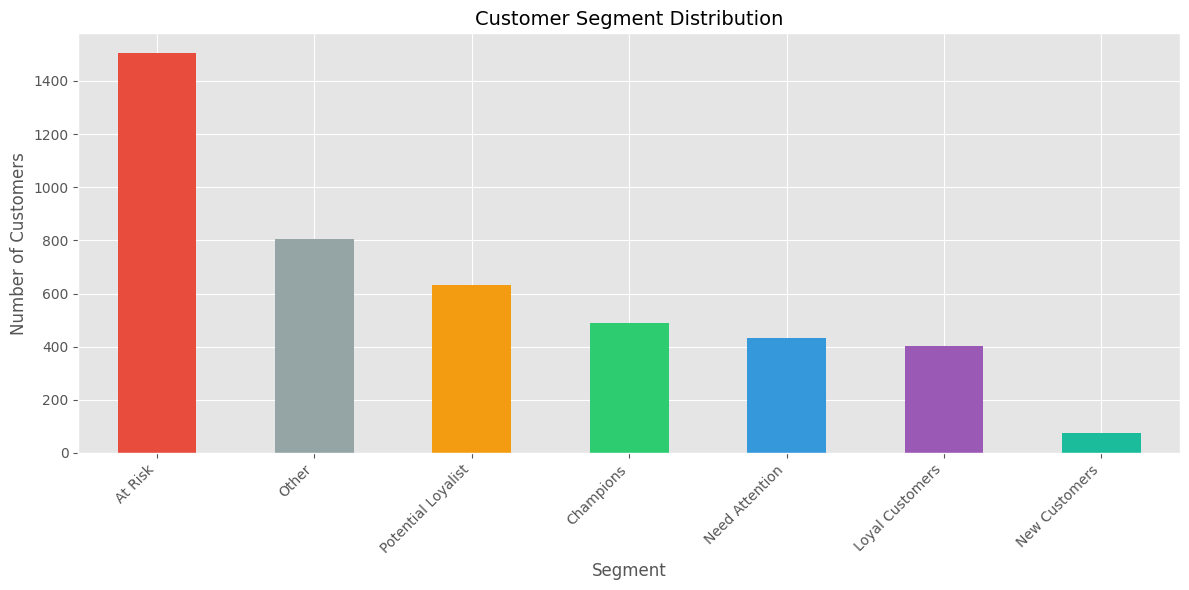

In [ ]:
print("="*50)
print("CUSTOMER SEGMENT VISUALIZATION")
print("="*50)

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 6))
segment_counts = rfm['Segment'].value_counts()
colors = ['#e74c3c', '#95a5a6', '#f39c12', '#2ecc71', '#3498db', '#9b59b6', '#1abc9c']
segment_counts.plot(kind='bar', color=colors[:len(segment_counts)])
plt.title('Customer Segment Distribution', fontsize=14)
plt.xlabel('Segment', fontsize=12)
plt.ylabel('Number of Customers', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [ ]:
print("="*50)
print("REVENUE CONTRIBUTION BY SEGMENT")
print("="*50)

segment_revenue = rfm.groupby('Segment')['Monetary'].agg(['sum', 'count']).sort_values('sum', ascending=False)
segment_revenue['percentage'] = (segment_revenue['sum'] / segment_revenue['sum'].sum()) * 100
print(segment_revenue.round(2))

print("\n" + "="*50)
print("KEY INSIGHTS")
print("="*50)

champions_pct = (rfm[rfm['Segment'] == 'Champions']['Monetary'].sum() / rfm['Monetary'].sum()) * 100
champions_cust = len(rfm[rfm['Segment'] == 'Champions'])
at_risk_revenue = rfm[rfm['Segment'] == 'At Risk']['Monetary'].sum()
at_risk_cust = len(rfm[rfm['Segment'] == 'At Risk'])

print(f"Champions ({champions_cust} customers / {champions_cust/len(rfm)*100:.1f}%) contribute {champions_pct:.1f}% of revenue")
print(f"At Risk ({at_risk_cust} customers) represents ${at_risk_revenue:,.2f} potential revenue loss")

REVENUE CONTRIBUTION BY SEGMENT
                           sum  count  percentage
Segment                                          
Champions           4434743.73    490       49.76
Potential Loyalist  1649816.20    632       18.51
Other               1303879.67    806       14.63
At Risk              767146.84   1504        8.61
Loyal Customers      516815.22    401        5.80
Need Attention       214278.65    431        2.40
New Customers         24727.59     74        0.28

KEY INSIGHTS
Champions (490 customers / 11.3%) contribute 49.8% of revenue
At Risk (1504 customers) represents $767,146.84 potential revenue loss


In [ ]:
print("="*50)
print("BUSINESS RECOMMENDATIONS")
print("="*50)

print("""
Based on the RFM analysis of 4,338 customers, the following recommendations are proposed:

================================================================================
1. CHAMPIONS (490 customers | 11.3% of customers | 49.8% of revenue)
================================================================================
   - Launch exclusive loyalty program with tiered benefits
   - Offer early access to new products and seasonal collections
   - Provide dedicated customer support line
   - Send personalized thank you notes and birthday gifts
   - Expected outcome: Maintain 95% retention rate

================================================================================
2. POTENTIAL LOYALIST (632 customers | 14.6% of customers | 18.5% of revenue)
================================================================================
   - Encourage more purchases with limited-time offers
   - Cross-sell complementary products
   - Free shipping on next purchase
   - Expected outcome: Convert 20% to Champions within 3 months

================================================================================
3. AT RISK (1,504 customers | 34.7% of customers | 8.6% of revenue)
================================================================================
   - Send win-back offers (10-15% discount)
   - Personalized email campaigns with product recommendations
   - Survey to understand churn reasons
   - Expected outcome: Recover 15% of At Risk customers

================================================================================
4. LOYAL CUSTOMERS (401 customers | 9.2% of customers | 5.8% of revenue)
================================================================================
   - Referral bonus program ($10 off for each referral)
   - Free shipping on minimum purchase ($50)
   - Birthday discounts (15% off)
   - Expected outcome: Increase average order value by 15%

================================================================================
5. NEED ATTENTION (431 customers | 9.9% of customers | 2.4% of revenue)
================================================================================
   - Re-engagement campaigns with limited time offers
   - Feedback request to understand pain points
   - Expected outcome: Reactivate 10% of this segment

================================================================================
6. NEW CUSTOMERS (74 customers | 1.7% of customers | 0.3% of revenue)
================================================================================
   - Welcome series emails (3 emails in first week)
   - First-purchase discount for next order (10% off)
   - Product recommendation based on first purchase
   - Expected outcome: Convert 30% to Loyal Customers

================================================================================
7. STRATEGIC ACTIONS
================================================================================
   - Focus marketing budget on Germany and France markets (top countries after UK)
   - Increase ad spend during October-November (peak season)
   - Implement automated RFM scoring dashboard for real-time tracking
   - Monthly review of segment migration

   TARGETS FOR NEXT 6 MONTHS:
   - Reduce At Risk segment from 34.7% to 25%
   - Increase Champions segment from 11.3% to 15%
   - Increase New Customers acquisition by 50%
   - Grow overall revenue by 15%
""")

BUSINESS RECOMMENDATIONS

Based on the RFM analysis of 4,338 customers, the following recommendations are proposed:

1. CHAMPIONS (490 customers | 11.3% of customers | 49.8% of revenue)
   - Launch exclusive loyalty program with tiered benefits
   - Offer early access to new products and seasonal collections
   - Provide dedicated customer support line
   - Send personalized thank you notes and birthday gifts
   - Expected outcome: Maintain 95% retention rate

2. POTENTIAL LOYALIST (632 customers | 14.6% of customers | 18.5% of revenue)
   - Encourage more purchases with limited-time offers
   - Cross-sell complementary products
   - Free shipping on next purchase
   - Expected outcome: Convert 20% to Champions within 3 months

3. AT RISK (1,504 customers | 34.7% of customers | 8.6% of revenue)
   - Send win-back offers (10-15% discount)
   - Personalized email campaigns with product recommendations
   - Survey to understand churn reasons
   - Expected outcome: Recover 15% of At Risk c